# 1. 引入模块

In [14]:
# 导入类型注解工具：用于变量类型约束、列表、字面量固定值
from typing import Annotated, List, Literal

# 导入TypedDict，用于自定义Graph状态字典结构
from typing_extensions import TypedDict

# 导入运算符模块，后续用于消息列表拼接累加
import operator

# ========== LangGraph 核心模块导入==========
# 导入状态图、起始节点、结束节点
from langgraph.graph import StateGraph, START, END
# 导入消息拼接工具，自动累加多轮对话消息
from langgraph.graph.message import add_messages

# ========== LangChain 消息模型导入==========
# 导入消息基类、用户消息、AI回复消息、工具调用消息
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
# 导入通用大模型初始化函数
from langchain.chat_models import init_chat_model

# 2. 定义状态

In [15]:
class AgentState(TypedDict):
    """多智能体的共享状态"""
    messages: Annotated[List[BaseMessage], add_messages]   # 对话历史
    topic: str                                             # 报告主题
    research_material: str                                 # 材料收集结果（修正拼写）
    final_article: str                                     # 最终报告
    next_agent: str                                        # 下一个智能体

# 3. 智能体（Model）:节点

In [16]:
model = init_chat_model(
    model="ollama:qwen3.6:latest",
    temperature=0.5,
    base_url="http://192.168.8.21:11434"
)

1. **材料收集主题**
    - 主题交给大模型，大模型自己去生成材料

In [17]:
def research_agent(state: AgentState) -> dict:
    topic = state["topic"]
    print(">>>正在收集材料...")
    prompt = f"请针对主题 '{topic}' 收集关键信息,用4-5个要点总结"
    response = model.invoke(prompt)
    print("\t|-【资料员】完成收集工作：", response.content)
    return {
        "research_material": response.content,   
        "next_agent": "writer"
    }

2. **写报告（文章）**
    - 主题+材料
    - 扔给大模型，生成最后的报告

In [18]:
def writer_agent(state: AgentState) -> dict:
    print(">>>正在疯狂写文章...")
    material = state["research_material"]        # 修正拼写
    topic = state["topic"]
    prompt = f"""基于以下研究的材料，撰写一篇关于 '{topic}' 的简短文章，要求字数500左右:

研究材料：
{material}

文章的要求：简洁，清晰，有吸引力，逻辑严谨；
"""
    response = model.invoke(prompt)
    print("\t|-【写手】完成写作任务：", response.content)
    return {
        "final_article": response.content,
        "next_agent": "end"                      # 使用 "end" 表示结束
    }

3. **监督者**
    - 根据状体直接安排工作

In [19]:
def supervisor_agent(state: AgentState):
    print(">>>主管在努力写作工作中。。。")
    if not state.get("next_agent"):
        next_agent = "researcher"
        print("$$$主管安排【资料员】开始工作")
    elif not state.get("final_article"):
        next_agent = "writer"
        print("$$$主管安排【写作员】开始工作")
    else:
        next_agent = "end"                     
        print("$$$主管已经完成工作安排")
    return {"next_agent": next_agent}

# 4. ***设计模式（交接模式）***

In [20]:
def should_continue(state: AgentState) -> Literal["researcher", "writer", "end"]:
    next_agent = state.get("next_agent")
    if next_agent == "researcher":
        return "researcher"
    elif next_agent == "writer":
        return "writer"
    else:
        return "end"          

In [21]:
# ====================== 1. 创建工作流图谱 ======================
# 基于我们定义的 AgentState 状态，创建一个多智能体工作流模板
multi_graph = StateGraph(AgentState)

# ====================== 2. 添加工作节点 ======================
# 每个节点 = 一个智能体/函数
# 参数：(节点名字, 对应的执行函数)
multi_graph.add_node("supervisor", supervisor_agent)  # 管理者智能体：分配任务
multi_graph.add_node("researcher", research_agent)    # 研究员智能体：查资料（修复拼写！）
multi_graph.add_node("writer", writer_agent)          # 写作智能体：写报告（修复顺序！）

# ====================== 3. 定义流程走向（边） ======================
# 起点 → 管理者（流程一开始就进入 supervisor）
multi_graph.add_edge(START, "supervisor")

# ---------------- 核心：条件分支（管理者决定下一步做什么） ----------------
# 格式：add_conditional_edges(
#     从哪个节点出发,
#     条件判断函数,
#     条件映射：{ 返回值: 跳转到哪个节点 }
# )
multi_graph.add_conditional_edges(
    "supervisor",
    should_continue,
    {
        "researcher": "researcher",
        "writer": "writer",
        "end": END            # 这里的 END 是 langgraph.graph.END 常量
    }
)

# ---------------- 普通边：任务完成后 → 返回管理者 ----------------
# 研究员做完 → 回到管理者
multi_graph.add_edge("researcher", "supervisor")
# 写作做完 → 回到管理者
multi_graph.add_edge("writer", "supervisor")

# ====================== 4. 编译工作流（生成可运行的图） ======================
# 编译后才能真正调用运行
multi_graph = multi_graph.compile()

# 5.业务调用

In [24]:
print("多智能体开始工作")

# 设定研究主题
topic = "西游记中的哲学法"

# 状态初始化（严格对应 AgentState 定义）
init_state = {
    "messages": [HumanMessage(content=f"研究主题：{topic}")],
    "topic": topic,             # 报告主题
    "research_material": "",    # 修复拼写：材料收集结果
    "final_article": "",        # 最终报告
    "next_agent": ""            # 下一个智能体
}

# 开始调用工作流（用你编译好的 multi_graph）
final_state = multi_graph.invoke(init_state)

# 输出结果（正确取值）
print("=" * 80)
print("最终生成的报告：")
print(final_state["final_article"])  # 修复字典键名
print("=" * 80)

多智能体开始工作
>>>主管在努力写作工作中。。。
$$$主管安排【资料员】开始工作
>>>正在收集材料...
	|-【资料员】完成收集工作： 针对“西游记中的哲学法”（通常指《西游记》所蕴含的**哲学思想与内涵**），结合明清思想史与文本细读，可提炼为以下4个核心要点：

1. **三教合一的哲学底色**  
   小说以明代“三教合一”思潮为思想基底，将佛教的因果轮回、道教的炼丹修仙、儒家的忠孝纲常有机融合。表层叙事以佛教取经为主线，中层结构暗合道教修炼体系，价值内核则落脚于儒家伦理秩序，形成“以释为表、以道为里、以儒为用”的复合哲学框架。

2. **心性修炼与“心猿”隐喻**  
   取经实为“修心”之旅。孙悟空（心猿）、猪八戒（欲望/意马）、沙僧（本性/调和）等角色构成人的心理结构，八十一难对应破除“贪嗔痴”等心魔的禅宗修行。文本反复强调“心生种种法生，心灭种种法灭”，体现佛教“明心见性”与“即心即佛”的心性论。

3. **道家内丹学与阴阳辩证**  
   大量降妖伏魔情节暗合道教内丹术（如“金丹”“火候”“五行生克”“铅汞相投”），将内在炼丹过程外化为叙事冲突。同时贯穿阴阳对立统一、物极必反的辩证思维，如“真假美猴王”（心性与妄念之辨）、“阴阳二气瓶”（刚柔相济）、“五行山”（五行制化）等，展现道家“反者道之动”的宇宙观。

4. **真妄之辨与精神超越**  
   通过“无字真经”与“有字真经”、“幻境”与“实境”的对照，探讨“色空不二”“即妄即真”的认识论命题。取经终点并非获取外在经文，而是破除对“相”的执着，回归本心。最终指向中国哲学“知行合一”“顿渐相资”的实践智慧，完成从“向外求法”到“向内证道”的精神超越。

> 注：若需进一步聚焦某一哲学流派（如纯禅宗视角、纯道教丹道视角）或结合具体章回/评点本（如李卓吾、悟一子评点），可提供补充方向。
>>>主管在努力写作工作中。。。
$$$主管安排【写作员】开始工作
>>>正在疯狂写文章...
	|-【写手】完成写作任务： **《西游》的哲学法：向内求证的修心之旅**

《西游记》绝非仅是一部神魔演义，而是一部以叙事为载体的哲学法典。其核心哲学法，可凝练为“三教合一”的复合架构与“向内证道”的心性修炼。

小说以明代“三教合一”为基底，构建“以释为表、以道为里、以儒为用”的哲学框架。表层取经暗合

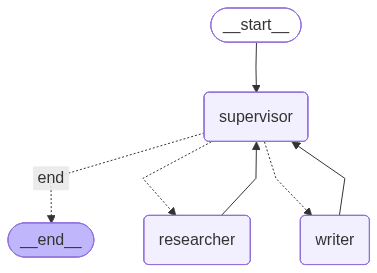

In [26]:
from IPython.display import Image,display
display(Image(multi_graph.get_graph(xray=False).draw_mermaid_png()))